# Semi-Supervised Training (SimCLR + Supervised) 
We start by downloading (loading) the model along with its transformations and tokenizers.

In [1]:
import open_clip
import torch
import json
import os
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import random
import matplotlib.pyplot as plt
from utils import plot_training_results
import torch.nn.functional as F
from tqdm import tqdm
import itertools



device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

# 1. Load the model, training transforms, and tokenizer
model_name = 'ViT-B-32'
pretrained_weights = 'openai'

model, base_train_transform, val_transform = open_clip.create_model_and_transforms(
    model_name, 
    pretrained=pretrained_weights
)

model = model.to(device)

tokenizer = open_clip.get_tokenizer(model_name)
print("Model and Tokenizer loaded successfully!")


/nobackup/marfr380/clip_venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cuda


/nobackup/marfr380/clip_venv/lib/python3.10/site-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


Model and Tokenizer loaded successfully!


# Dataset
We can start by taking a look at the data we have access to.

According to the project document, we have the following splits:
* Split A (referred to as “train” in the json file; 8734 images) – This will be treated as
the unlabeled dataset for semi-supervised fine-tuning. Only images, no captions,
can be used in this project!
* Split B (referred to as “validation” in the json file; 1094 images) – This will be treated
as the labeled dataset for training (images with captions). It is suggested to further
split this into “real” training and validation sets.
* Split C (referred to as “test” in the json file; 1093 images) – This will be treated as
the labeled dataset for final evaluation (images with captions and class labels).

In [2]:
with open("data/dataset_rsicd.json", "r") as f:
    data = json.load(f)
images = data["images"][0]
print("Images has the following keys:", " | ".join(list(images.keys())))
print("Name of our dataset:", data['dataset'])

# Lets divide the data into their respective splits:
splitA = [i for i in data["images"] if i["split"] == "train"] # (Unlabeled dataset) Not allowed to use sentences
splitB = [i for i in data["images"] if i["split"] == "val"]   # (Labeled dataset) Allowed to use sentences
splitC = [i for i in data["images"] if i["split"] == "test"]  # Actual tess dataset for evaluating performance
print("Splits loaded...")

Images has the following keys: filename | imgid | sentences | split | sentids
Name of our dataset: RSICD
Splits loaded...


In [3]:
# Created a new utility function that loads all the splits, which includes their respective classes.
from utils import load_dataset

splitA, splitB, splitC = load_dataset("data/dataset_rsicd.json", classes=True)

There are some more details regarding the sentences in the project descriptions:
* *Note that each image is accompanied by five text descriptions (captions). It is recommended to utilize all of the captions from Split B during training*

So, we can take a look at some random examples of this below.

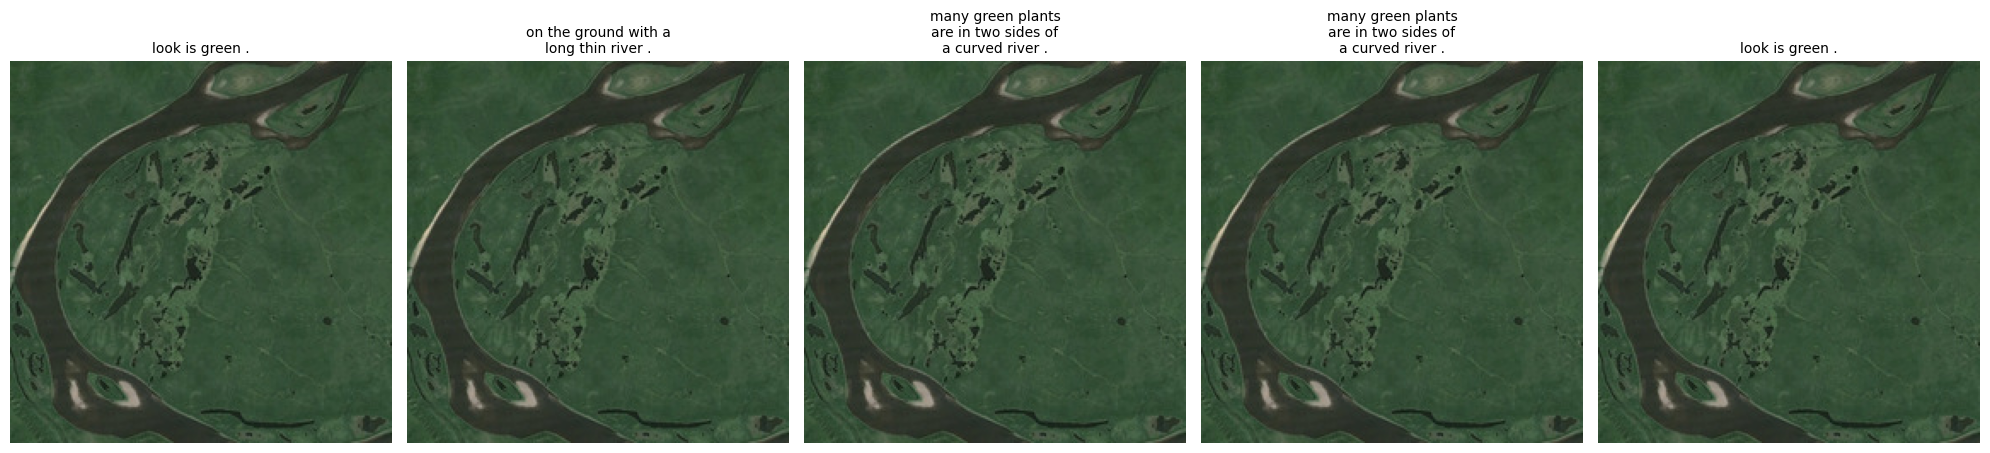

In [4]:
import textwrap
example = splitB[random.randint(0, len(splitB))]
image = Image.open(f"data/RSICD_images/{example['filename']}")
descriptions = [sent['raw'] for sent in example['sentences']]

# Assuming 'image' and 'descriptions' are already defined from your snippet
fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i, ax in enumerate(axes):
    ax.imshow(image)
    # Wrap text so it doesn't run off the side of the subplot
    wrapped_text = textwrap.fill(descriptions[i], width=20)
    ax.set_title(wrapped_text, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Transformations
**ViT-B-32** only accepts images of size *224x224*. This is part of what the transformations we get when downloading the model `base_train_transform` and `val_transform`, they crop the images in different ways and normalizes the pixels to values that the model saw during training. 
* `base_train_transform` would normaly crop a random patch in the image and scales it down to 224x224, followed by rest of the transformations, it does this so that the training becomes more varied.
* `val_transform` is what is used for real world examples, it does a "center crop" - taking the biggest possible square in the center of the image and then scales it down, followed by the reamining transformations.

For our given RSICD Dataset, it seems that all the given images are already of the size *224x224*, which means the actual transform will only normalize the pixel values.
We can try to visualize it, but the results might look quite bad. (the normalization also puts the pixel values in the negative range, which is not valid in matplotlib)

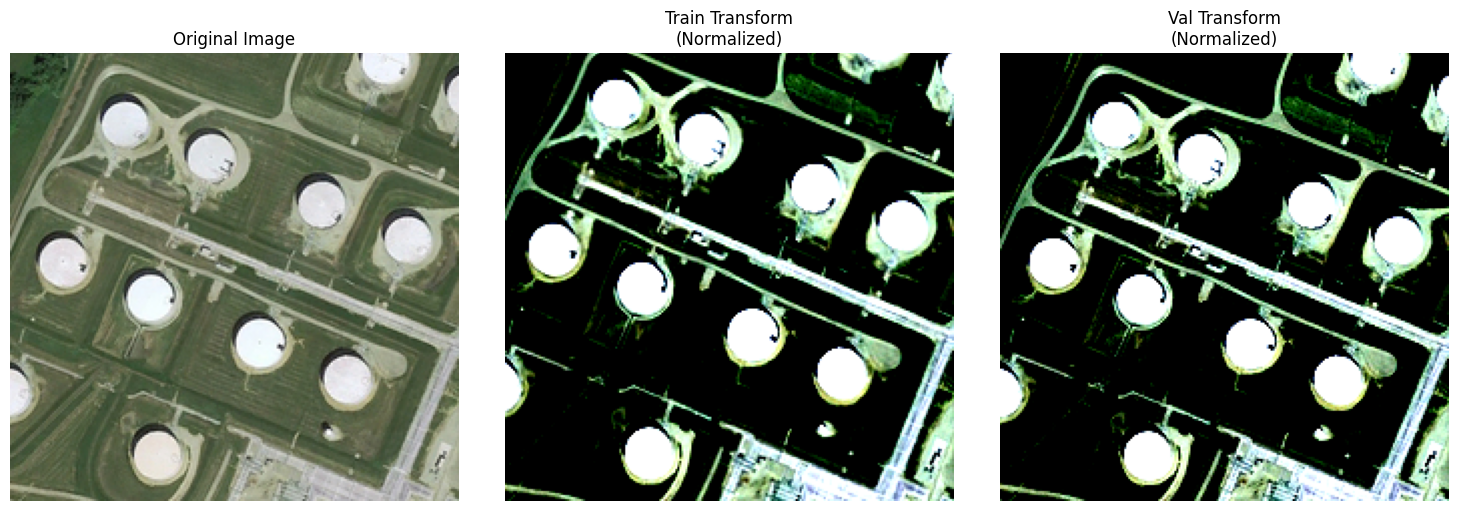

In [5]:
# 1. Get a sample image
example_item = splitB[random.randint(0, len(splitB))] 
raw_img = Image.open(f"data/RSICD_images/{example_item['filename']}").convert('RGB')

# 2. Apply the transforms (these return Tensors)
img_train_tensor = base_train_transform(raw_img)
img_val_tensor = val_transform(raw_img)

# 3. Plotting logic
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Original (PIL Image works directly with imshow)
axes[0].imshow(raw_img)
axes[0].set_title("Original Image", fontsize=12)

# Training Transform (Must swap dimensions from CxHxW to HxWxC)
# We use .permute(1, 2, 0) to move the Color channel to the end
axes[1].imshow(img_train_tensor.permute(1, 2, 0))
axes[1].set_title("Train Transform\n(Normalized)", fontsize=12)

# Validation Transform
axes[2].imshow(img_val_tensor.permute(1, 2, 0))
axes[2].set_title("Val Transform\n(Normalized)", fontsize=12)

for ax in axes:
    ax.axis('off')

plt.tight_layout()
plt.show()

# SimCLR Transformations
Previously we have only looked at rather simple transformations which are typically used when doing **image-text contrastive learning**. 

In that case, we usually only perform mild augmentations—like randomly cropping the image to a valid tensor size. We do this because we want to retain as much original detail as possible. Since the model is learning to align an image with a specific text description, heavily distorting the image could destroy the exact visual information the text is referring to.

On the other hand, when performing unlabeled training with **SimCLR**, our goal is to force the model to learn a rich, robust understanding of images without any text descriptions to guide it. To achieve this, we train the model to map "similar" images close to each other in the embedding space. 

However, if we only optimize for similarity, the model will quickly find a trivial solution: predicting the exact same embedding (e.g., a vector of all `0.0`s) for every single image. This would technically achieve a perfect similarity score, but it destroys any meaningful representation. This failure mode is known as **model collapse**. 

To prevent model collapse, contrastive learning algorithms like SimCLR introduce **negative samples**. The objective becomes dual-purpose: the model must pull similar images close together, while simultaneously pushing dissimilar images as far apart as possible. This push-and-pull dynamic prevents collapse. If the model lazily outputs all zeros, it might get a perfect score for similar images, but it will receive a massive penalty for failing to separate the dissimilar ones.

But how do we know which images are similar and dissimilar in an unlabeled dataset? We use a **self-supervised approach** driven by heavy data augmentation. 

For every image, we apply two completely random series of transformations (like random crops, heavy color distortions, blurring, and flips) to create two distinct "views" of the original image. Because these two views originate from the same image, they act as our **positive pair**. By forcing the model to recognize that a heavily color-jittered crop and a flipped grayscale crop still depict the same semantic content, the model learns to ignore superficial pixel-level noise and extract the core, invariant features of the object.

During training, we apply this process to a full batch of $N$ original images, resulting in $2N$ augmented images. For any given image in this batch, the math works out perfectly:
*   **1** positive example (its differently augmented twin).
*   **$2N - 2$** negative examples (every other augmented image in the batch). 

We can showcase what this will look like with an example:

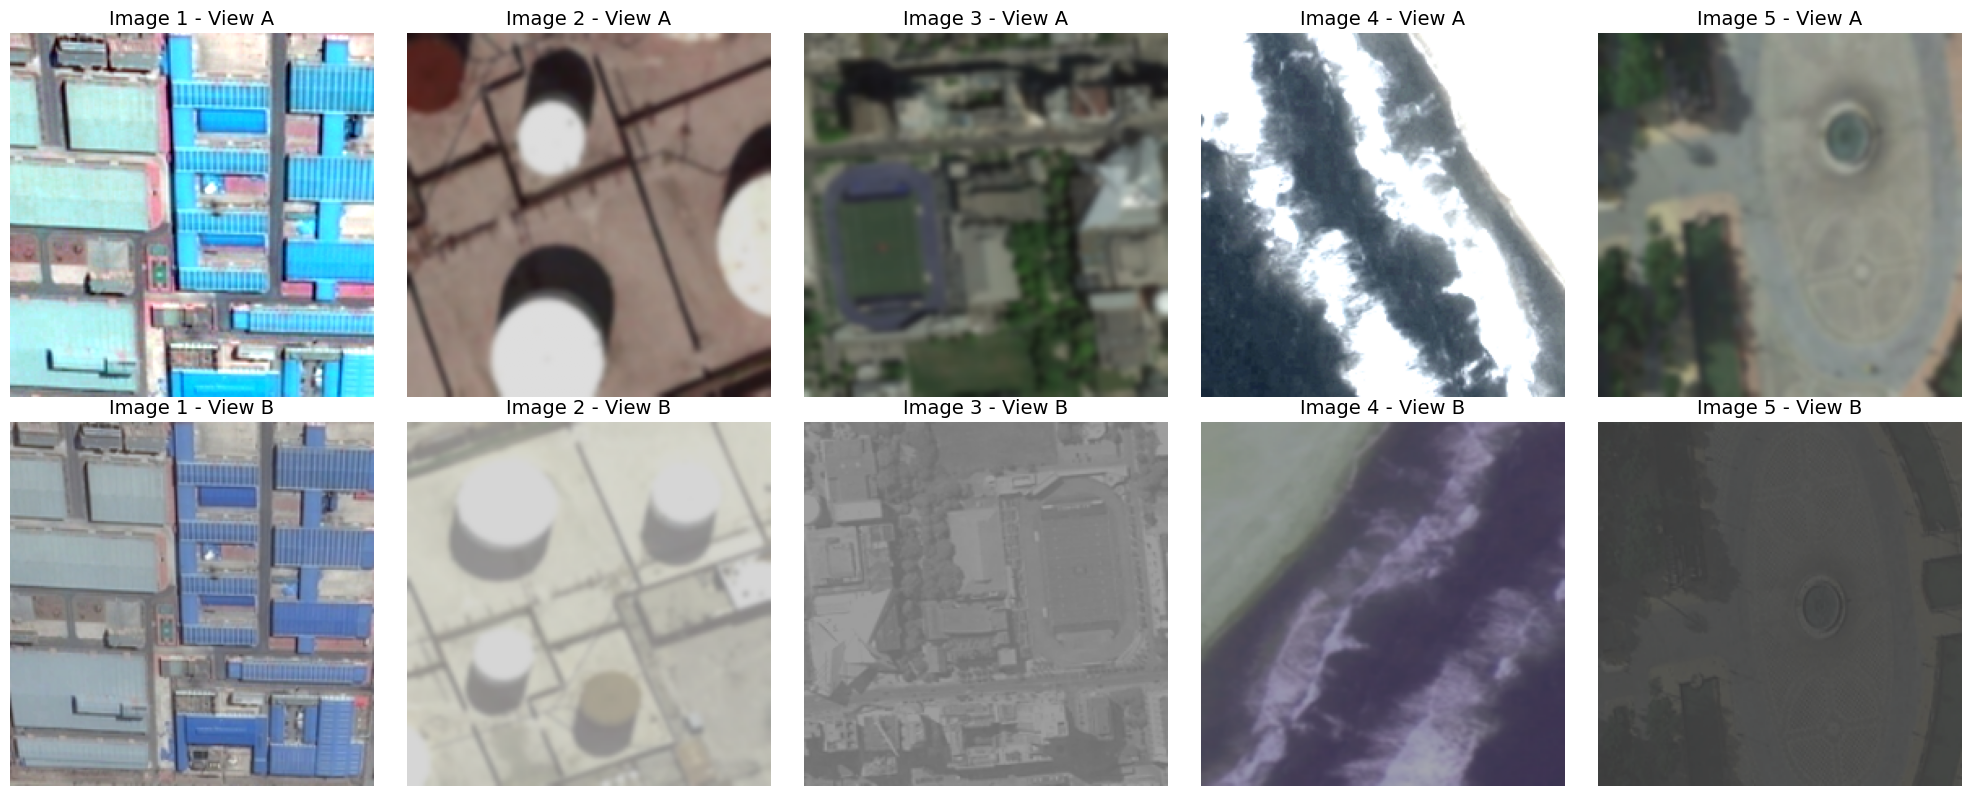

In [6]:
# 1. Define the SimCLR transform WITHOUT normalization
simclr_transform = T.Compose([
    # Spatial: Aggressive Crop and Resize
    T.RandomResizedCrop(224, scale=(0.2, 1.0)), 
    
    # Spatial: Flips & Rotations
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    
    # Visual: Color Distortion
    T.RandomApply([T.ColorJitter(0.8, 0.8, 0.8, 0.2)], p=0.8),
    T.RandomGrayscale(p=0.2),
    
    # Visual: Gaussian Blur (Helps prevent the model from memorizing sharp high-frequency noise)
    T.RandomApply([T.GaussianBlur(kernel_size=23, sigma=(0.1, 2.0))], p=0.5),
    
    # Convert to Tensor
    T.ToTensor(),
])

# Select 5 random images from Split A (the unlabeled data)
random_samples = random.sample(splitA, 5)

# Create a 2x5 grid plot (2 rows, 5 columns)
fig, axes = plt.subplots(2, 5, figsize=(20, 8))

for i, item in enumerate(random_samples):
    # Load the raw image
    img_path = f"data/RSICD_images/{item['filename']}"
    raw_img = Image.open(img_path).convert('RGB')
    
    # Create two completely different augmented views of the SAME image
    view_1 = simclr_transform(raw_img)
    view_2 = simclr_transform(raw_img)
    
    # Top Row: View 1
    # .permute(1, 2, 0) changes shape from [Channels, Height, Width] to [Height, Width, Channels]
    axes[0, i].imshow(view_1.permute(1, 2, 0))
    axes[0, i].set_title(f"Image {i+1} - View A", fontsize=14)
    axes[0, i].axis('off')
    
    # Bottom Row: View 2
    axes[1, i].imshow(view_2.permute(1, 2, 0))
    axes[1, i].set_title(f"Image {i+1} - View B", fontsize=14)
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()

# Creating our Datasets for Training.
Since we are not allowed to do any testing or hyperparameter tuning on Split C, we have to instead use Split B to create our training and test splits.

We can do this by shuffling our data and then splitting it up into two parts of a desired percentage.

In [7]:
# Define split sizes
training_size = 0.9

# Reproducibility
random.seed(42)

# Shuffle our data
random.shuffle(splitB)
splitIdx = int(len(splitB) * training_size) 

splitB_tr = splitB[:splitIdx]
splitB_te = splitB[splitIdx:]

print(f"Original total:    {len(splitB):>5}")
print(f"Training samples:  {len(splitB_tr):>5} ({training_size*100:.0f}%)")
print(f"Validation samples: {len(splitB_te):>5} ({(1-training_size)*100:.0f}%)")

Original total:     1094
Training samples:    984 (90%)
Validation samples:   110 (10%)


# Datasets & DataLoaders
Now that we have our splits ready - we can initialize our Dataset classes.
For every image in splitB, there is actually going to be 5 training examples, because each image has as we saw earlier 5 captions. 
Our Dataset class will take care of creating separate examples for all of them.

As for our Split A, since we do not use any captions, we are going to have exactly as many training examples as we have images. Although since we will create random views of every image as we load our batches, one could argue we have a lot more examples.

In [8]:
from rsiddataset import RSICDUnlabeledDataset, RSICDLabeledDataset

image_dir = "data/RSICD_images"


# Extract the exact normalization layer from the official CLIP transform
clip_normalize = base_train_transform.transforms[-1] 

simclr_transform = T.Compose([
    # 1. Extreme Cropping: Force it to look at tiny, distinct parts of the image
    T.RandomResizedCrop(224, scale=(0.1, 0.5)), 
    
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=(0, 180)),
    
    # 2. Brutal Color Jitter: Destroy the "color matching" cheat code
    T.RandomApply([T.ColorJitter(0.8, 0.8, 0.8, 0.2)], p=0.8),
    
    # 3. Grayscale is back: 20% of the time, the model must rely ONLY on shapes
    T.RandomGrayscale(p=0.2),
    
    T.ToTensor(),
    
    # 4. Random Erasing: Cut out blocks of pixels so it can't rely on a single feature
    T.RandomErasing(p=0.5, scale=(0.05, 0.2)),
    
    clip_normalize
])

training_a = RSICDUnlabeledDataset(splitA, img_dir=image_dir, transform=simclr_transform)

training_b = RSICDLabeledDataset(splitB_tr, img_dir=image_dir, transform=base_train_transform, tokenizer=tokenizer)
test_b     = RSICDLabeledDataset(splitB_te, img_dir=image_dir, transform=base_train_transform, tokenizer=tokenizer)

# Print number of examples in each dataset
print(f"Training A (Unlabeled):  {len(training_a):>6} images")
print(f"Training B (Labeled):    {len(training_b):>6} caption-image pairs")
print(f"Validation B (Labeled):  {len(test_b):>6} caption-image pairs")

Training A (Unlabeled):    8734 images
Training B (Labeled):      4920 caption-image pairs
Validation B (Labeled):     550 caption-image pairs


In [9]:
loader_args = {
    "batch_size": 64,
    "num_workers": 12,
    "pin_memory": True,
    "drop_last": True,
}

loader_A = DataLoader(training_a, shuffle=True, **loader_args)
loader_B = DataLoader(training_b, shuffle=True, **loader_args)

# Validation doesn't need drop_last or shuffle, and can have a higher batch size
val_loader_B = DataLoader(test_b, batch_size=256, shuffle=False, drop_last=False)

In [10]:
@torch.no_grad()
def evaluate_zero_shot(model, dataloader, class_names, tokenizer):
    model.eval()

    prompts = [f"A satellite image of a {cls_name.lower()}." for cls_name in class_names]
    text_tokens = tokenizer(prompts).to(device)

    text_features = model.encode_text(text_tokens)
    text_features = F.normalize(text_features, dim=-1)

    correct = 0
    total = 0

    pbar = tqdm(dataloader, desc="Zero-Shot Evaluation")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)
        
        # Encode and normalize images
        image_features = model.encode_image(images)
        image_features = F.normalize(image_features, dim=-1)
        
        # Calculate Cosine Similarity
        # Shape: [Batch_Size, Num_Classes]
        similarity = image_features @ text_features.T 
        
        # The predicted class is the one with the highest similarity score
        predictions = similarity.argmax(dim=-1)
        
        # Count correct predictions
        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    final_accuracy = correct / total
    return final_accuracy

In [11]:
from rsiddataset import RSICDClassificationDataset

unique_classes = sorted(list(set(item['class'] for item in splitC)))
zs_dataset = RSICDClassificationDataset(
    image_list=splitC, 
    img_dir="data/RSICD_images", 
    transform=val_transform, 
    class_names=unique_classes
)

zs_loader = DataLoader(zs_dataset, batch_size=64, shuffle=False, num_workers=4)

accuracy = evaluate_zero_shot(model, zs_loader, unique_classes, tokenizer)
print(accuracy)

Zero-Shot Evaluation:   0%|          | 0/18 [00:00<?, ?it/s]

Zero-Shot Evaluation: 100%|██████████| 18/18 [00:01<00:00, 10.78it/s]


0.5032021957913998


# Training our Model
Now that we plan to train our model using both labeled image-caption pairs and unlabeled images, we need a unified loss function capable of handling both scenarios seamlessly.

Our core objective is to map related inputs close together in a shared embedding space. For labeled data, an image and its corresponding text description should yield highly similar embeddings. For unlabeled data, we apply the exact same logic: because we generate two different augmented views of a single image, we can treat these two views just like an image-caption pair. Their embeddings should be pulled close together. 

Equally important is the repulsive force: the embeddings of *unrelated* images (or unrelated texts) must be pushed as far apart as possible to prevent the model from collapsing to a single point.

### Example:
Let's say we have a batch size of 64. Depending on the training step, this batch consists of either 64 image-caption pairs or 64 images processed into two augmented views each (yielding 64 positive image-image pairs).

The model's objective can be framed as a multiple-choice classification task over the batch. For any given image, the model must "guess" which of the 64 text captions (or 64 counterpart views) is the correct match. 

Crucially, this objective is **bidirectional** (symmetric). Just as the model learns to match an image to its correct text, it must simultaneously learn to match the text to its correct image. 

In practice, this is implemented using **InfoNCE** loss. The step-by-step process is:
*   **Normalize the embeddings:** Apply L2 normalization to all output vectors.
*   **Calculate similarity scores:** Compute the pairwise dot product for all embeddings in the batch. Because the vectors are normalized, this is equivalent to calculating the Cosine Similarity.
*   **Apply Temperature Scaling:** Divide the similarity scores by a learnable or fixed *temperature parameter* ($\tau$). This is a vital step in contrastive learning that controls the sharpness of the predictions and helps the model learn from hard negatives.
*   **Convert to probabilities:** Apply a Softmax function across the scaled similarities to get a probability distribution for each pair.
*   **Calculate Cross-Entropy Loss:** Compute the standard cross-entropy loss for both directions (e.g., Image $\rightarrow$ Text and Text $\rightarrow$ Image).
*   **Average the loss:** Calculate the mean of the two directional losses to get the final loss for the batch.

In [12]:

def info_nce_loss(features_1, features_2, logits_scale):
    # L2 Normalization (L_p, but p is 2 by default)
    feat_1 = F.normalize(features_1)
    feat_2 = F.normalize(features_2)

    # Calculate similarity scores
    # [N, Dim] @ [Dim, N] -> [N, N] similarity matrix
    logits = logits_scale * feat_1 @ feat_2.T

    # Define ground truth labels
    # The diagonal is our target, so for every row, the target is at the same index as the row.
    labels = torch.arange(len(logits)).to(device)
    
    # Calculate bidirectional cross-entropy loss.
    loss_1 = F.cross_entropy(logits, labels)
    loss_2 = F.cross_entropy(logits.T, labels)

    # Return the average of the losses
    return (loss_1 + loss_2) / 2.0

@torch.no_grad()
def evaluate_clip_loss(model, val_loader, logits_scale):
    model.eval()
    val_loss = 0.0
    num_batches = 0

    for images, tokens in val_loader:
        images, tokens = images.to(device), tokens.to(device)
        
        feat_img = model.encode_image(images)
        feat_tok = model.encode_text(tokens)

        loss = info_nce_loss(feat_img, feat_tok, logits_scale)

        val_loss += loss.item()
        num_batches += 1
    
    return val_loss / num_batches

import time

def train_clip(
        model, 
        labeled_loader, 
        unlabeled_loader, 
        val_loader,
        zs_loader,
        num_classes,
        optimizer, 
        epochs=10, 
        lambda_unsup=1.0, 
        temperature=None,
        freeze_text_encoder=False,
        debug=False,
        compile=False,
        clip_norm=1.0,
    ):
    if compile:
        model = torch.compile(model)

    if freeze_text_encoder:
        for param in model.transformer.parameters():
            param.requires_grad = False
        if hasattr(model, 'token_embedding'):
            model.token_embedding.requires_grad = False
            
    if temperature:
        model.logit_scale.requires_grad = False
        fixed_scale = torch.Tensor(1.0 / temperature).to(device)

    epoch_sup_losses    = []
    epoch_unsup_losses  = []
    epoch_total_losses  = []
    epoch_val_losses    = []
    epoch_zs_accuracies = []


    # Use the loaders passed in as arguments
    loader_B_cycled = itertools.cycle(labeled_loader)

    for epoch in range(epochs):
        model.train()
        pbar = tqdm(unlabeled_loader, desc=f"Epoch {epoch+1}/{epochs}")

        epoch_unsup_loss = 0.0
        epoch_sup_loss   = 0.0
        epoch_total_loss = 0.0
        n_batches = 0
        
        # Benchmarking variables
        total_fetch_time = 0
        total_compute_time = 0

        # Start timer for the first fetch
        start_time = time.time()

        for step, (view_1, view_2) in enumerate(pbar):
            
            # --- MEASURE DATA FETCH ---
            img_B, txt_B = next(loader_B_cycled)

            img_B = img_B.to(device)
            txt_B = txt_B.to(device)
            view_1 = view_1.to(device)
            view_2 = view_2.to(device)
            
            fetch_done_time = time.time()
            total_fetch_time += (fetch_done_time - start_time)

            # --- MEASURE COMPUTE ---

            optimizer.zero_grad()
            with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
                current_scale = fixed_scale if temperature else model.logit_scale.exp()
                
                feat_img_B = model.encode_image(img_B)
                feat_txt_B = model.encode_text(txt_B)
                feat_view_1 = model.encode_image(view_1)
                feat_view_2 = model.encode_image(view_2)

                sup_loss   = info_nce_loss(feat_img_B, feat_txt_B, current_scale)
                unsup_loss = info_nce_loss(feat_view_1, feat_view_2, current_scale)
                total_loss = sup_loss + (lambda_unsup * unsup_loss) 

            total_loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=clip_norm)
            optimizer.step()
            
            compute_done_time = time.time()
            total_compute_time += (compute_done_time - fetch_done_time)

            # Update stats
            epoch_sup_loss   += sup_loss.item() 
            epoch_unsup_loss += unsup_loss.item()
            epoch_total_loss += total_loss.item()
            n_batches        += 1

            if torch.cuda.is_available():
                used_mem = torch.cuda.max_memory_allocated(device) / 1024**3
                total_mem = torch.cuda.get_device_properties(device).total_memory / 1024**3
                mem_report = f"{used_mem:.1f}/{total_mem:.1f}GB"

            pbar.set_postfix({
                'Sup': f"{sup_loss.item():.3f}", 
                'Unsup': f"{unsup_loss.item():.3f}",
                'GPU': mem_report
            })
            
            # Start timer for next batch fetch
            start_time = time.time()
            
            # Print benchmark summary every 50 steps
            if debug and (step + 1) % 50 == 0:
                avg_fetch = total_fetch_time / (step + 1)
                avg_comp = total_compute_time / (step + 1)
                print(f"\nStep {step+1} Benchmark | Data: {avg_fetch:.3f}s | GPU: {avg_comp:.3f}s")
        
        validation_loss = evaluate_clip_loss(model, val_loader, current_scale)
        zs_accuracy = evaluate_zero_shot(model, zs_loader, num_classes, tokenizer)

        epoch_sup_losses.append(epoch_sup_loss/n_batches)
        epoch_unsup_losses.append(epoch_unsup_loss/n_batches)
        epoch_total_losses.append(epoch_total_loss/n_batches)
        epoch_val_losses.append(validation_loss)
        epoch_zs_accuracies.append(zs_accuracy)

        print(f"Epoch {epoch+1:03d} Complete | Avg Val Loss: {validation_loss:.4f} | Zero-Shot Accuracy: {zs_accuracy * 100:.1f}%")

    return {
            'supervised_losses': epoch_sup_losses,
            'unsupervised_losses': epoch_unsup_losses,
            'total_losses': epoch_total_losses,
            'validation_losses': epoch_val_losses,
            'epoch_zs_accuracies': epoch_zs_accuracies
            }


# Key changes
Training was initially quite slow (taking around 2s per batch), we suspected it could be the DataLoaders - since they are doing quite extensive transformations and have quite a large batch size combined.
By benchmarking the times for loading the data and computing the forward + backward separately - we figure out that we were right, the DataLoaders were huge bottlenecks.
### DataLoader Optimization Benchmark
*Note: BATCH_SIZE = 64 for all experiments.*
| Configuration | Throughput (it/s) | Total Time (s/it) | Data Time (Avg) | **Data Speedup** | GPU Time (Avg) | **Overall Speedup** |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **0 Workers** | 0.41 | 2.440s | 1.417s | 1.0x | 0.702s | 1.0x (Baseline) |
| **4 Workers** | 1.03 | 0.971s | 0.067s | **21.2x** | 0.723s | 2.5x |
| **4 Workers + Pin Memory** | 1.03 | 0.971s | **0.052s** | **27.3x** | 0.745s | **2.5x** |

---

Adding multiple workers gave us a huge speedup, letting our CPU prepare the batch in the background in parallel while our GPU was working - instead of only starting to prepare the next batch once the GPU was done.

### Compute bottleneck
We are no longer bottlenecked by the DataLoaders, the GPU time is now one OOM bigger than the CPU time.
### Mixed precision
Since we are running our experiments on a RTX 4000, we have access to mixed precision, and can possibly benefit from using `bfloat16`, which is a single line change in our training loop:

```py
with torch.autocast(device_type="cuda", dtype=torch.bfloat16):
```
### BF16 (mixed precision) Benchmark

| Configuration | Throughput (it/s) | Total Time (s/it) | Data Time (Avg) | GPU Time (Avg) | GPU Memory | **Overall Speedup** |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **0 Workers (FP32)** | 0.41 | 2.440s | 1.417s | 0.702s | ~10.8 GB | 1.0x (Baseline) |
| **4 Workers + Pin (FP32)** | 1.03 | 0.971s | **0.052s** | 0.745s | ~9.6 GB | 2.5x |
| **4 Workers + Pin (BF16)** | **1.84** | **0.543s** | 0.214s* | **0.231s** | **6.3 GB** | **4.5x** |

---

Mixed precision actually gave us quite a significant speedup. However, it also made our DataLoaders much slower - because they have way less time to work in the background now, since our GPU work is too fast.

One additional benefit we got from changing to mixed precision is that we went from using around **10GB** of VRAM to only **6.3GB**. This means we can at the very least double our batch size safely - which is both good in the sense of training a contrastive model, because it gives us more negative examples, but also because it makes our epochs faster.

### More DataLoader Optimizations
Taking a look at the CPU in the computer we are using for our experiments, it actually has **20 Cores** and **28 Threads**. We are only using 4 workers (per DataLoader), which means we are only utilizing 8 threads. So we should be able to safely increase the number of workers and be able to speedup the Data Loading.

| Configuration | Throughput (it/s) | Data Time (Avg) | GPU Time (Avg) | **Overall Speedup** |
| :--- | :---: | :---: | :---: | :---: |
| **0 Workers (Baseline, FP32)** | 0.41 | 1.417s | 0.702s | 1.0x |
| **4 Workers + Pin (BF16)** | 1.84 | 0.232s | 0.221s | 4.48x |
| **8 Workers + Pin (BF16)** | **3.27** | **0.095s** | **0.214s** | **7.97x** |
| **12 Workers + Pin (BF16)** | 2.70 | 0.112s | 0.215s | 6.58x |

---

From the experiments we did, there seems to be diminishing returns after a certain number of workers. It seems like using 8 workers per DataLoader might be the sweet spot.

### JIT Compilation
Another normal speedup is using `torch.compile()` which we tried doing, but it gave no significant speedup. We still leave it in the training loop as an option `compile=True`.

Zero-Shot Evaluation: 100%|██████████| 18/18 [00:01<00:00, 10.72it/s]


Epoch 001 Complete | Avg Val Loss: 2.9463 | Zero-Shot Accuracy: 73.7%


Zero-Shot Evaluation: 100%|██████████| 18/18 [00:01<00:00, 10.66it/s]


Epoch 002 Complete | Avg Val Loss: 3.6108 | Zero-Shot Accuracy: 71.5%


Zero-Shot Evaluation: 100%|██████████| 18/18 [00:01<00:00, 10.73it/s]


...

Epoch 008 Complete | Avg Val Loss: 3.9619 | Zero-Shot Accuracy: 75.0%


Zero-Shot Evaluation: 100%|██████████| 18/18 [00:01<00:00, 10.62it/s]


Epoch 009 Complete | Avg Val Loss: 3.7815 | Zero-Shot Accuracy: 75.1%


Zero-Shot Evaluation: 100%|██████████| 18/18 [00:01<00:00, 10.61it/s]


Epoch 010 Complete | Avg Val Loss: 3.8611 | Zero-Shot Accuracy: 74.5%


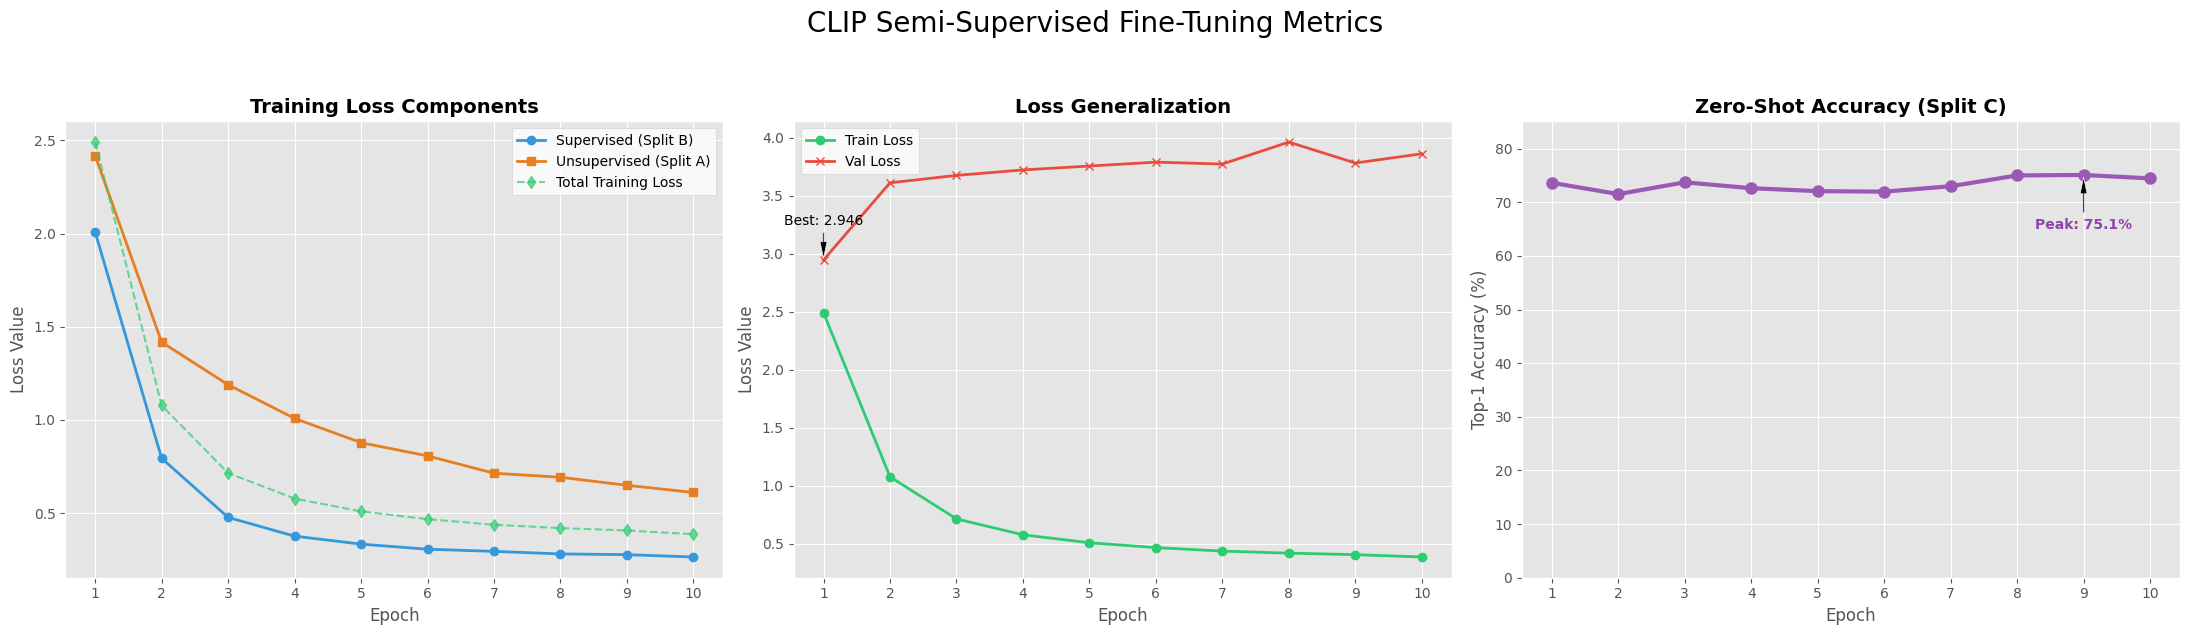

In [13]:
lr = 1e-5
optim = torch.optim.AdamW(model.parameters(), lr=lr)

loader_args = {
    "batch_size": 192,
    "num_workers": 8,
    "pin_memory": True,
    "drop_last": True
}

# B2B SAS någon?

loader_A = DataLoader(training_a, shuffle=True, **loader_args)
loader_B = DataLoader(training_b, shuffle=True, **loader_args)

# Validation doesn't need drop_last or shuffle, and can have a higher batch size
val_loader_B = DataLoader(test_b, batch_size=256, shuffle=False, drop_last=False)

metrics = train_clip(model=model, 
           labeled_loader=loader_B, 
           unlabeled_loader=loader_A, 
           val_loader=val_loader_B, 
           zs_loader=zs_loader,
           num_classes=unique_classes,
           optimizer=optim, 
           epochs=10, 
           lambda_unsup=0.2,
           debug=False,
           )


plot_training_results(metrics)

In [14]:
from rsiddataset import RSICDClassificationDataset

unique_classes = sorted(list(set(item['class'] for item in splitC)))
zs_dataset = RSICDClassificationDataset(
    image_list=splitC, 
    img_dir="data/RSICD_images", 
    transform=val_transform, 
    class_names=unique_classes
)

zs_loader = DataLoader(zs_dataset, batch_size=64, shuffle=False, num_workers=4)

accuracy = evaluate_zero_shot(model, zs_loader, unique_classes, tokenizer)
print(accuracy)

Zero-Shot Evaluation: 100%|██████████| 18/18 [00:01<00:00, 10.67it/s]

0.7447392497712717


In [ ]:
model_save_dir = "/nobackup/marfr380/models"
save_path = os.path.join(model_save_dir, "clip_best_model.pt")
torch.save(model.state_dict(), save_path)